In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error
import tensorflow as tf
import random
import keras

In [2]:
import sys
import os
sys.path.append(os.path.abspath("../../"))
from LSTM.preprocessing import parse_start_time, convert_to_datetime, create_sequences, prepare_sequences_from_cycles


In [3]:
SP = 50
LOOK_BACK = 30
SAMPLE_NUM = SP - LOOK_BACK
TIMESTEPS = 168 - SP

In [4]:
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

In [5]:
discharge_dataset = pd.read_csv("../../../dataset/processed/preprocessed_discharge_data.csv")

In [6]:
discharge_data_B0005 = discharge_dataset[discharge_dataset["battery_id"] == "B0005"].copy()
discharge_data_B0018 = discharge_dataset[discharge_dataset["battery_id"] == "B0018"].copy()

## Extract features

### Take 175 timesteps in each of the cycle, and then concatenate 168 cycles, each cycle have 5 features

In [7]:
columns = ['Voltage_measured', 'Current_measured', 'Temperature_measured', 'Current_load', 'Voltage_load']
data_path = "../../../dataset/processed/data"

X_B0005 = prepare_sequences_from_cycles(discharge_data_B0005, data_path, columns)
X_B0018 = prepare_sequences_from_cycles(discharge_data_B0018, data_path, columns)

X = np.concatenate([np.array(X_B0005), np.array(X_B0018)], axis=0)

100%|██████████| 132/132 [00:00<00:00, 247.88it/s]


In [8]:
# (cycles, each rows in a cycle, features)
X.shape

(300, 175, 5)

In [9]:
timesteps = X.shape[1]
features = X.shape[2]
latent_dim = 12

In [10]:
from keras.api.models import Model, Sequential
from keras.api.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense
from keras.api.utils import plot_model
from keras.api.optimizers import Adam
from keras.api.callbacks import EarlyStopping, ModelCheckpoint
from keras.api.metrics import RootMeanSquaredError

input_layer = Input(shape=(timesteps, features))
encoded = LSTM(64, activation='sigmoid', return_sequences=True)(input_layer)
encoded = LSTM(32, activation='sigmoid', return_sequences=False)(encoded)
encoded = Dense(latent_dim, activation='relu', name='bottleneck')(encoded)

decoded = RepeatVector(timesteps)(encoded)
decoded = LSTM(32, activation='sigmoid', return_sequences=True)(decoded)
decoded = LSTM(64, activation='sigmoid', return_sequences=True)(decoded)
decoded = TimeDistributed(Dense(features, activation='linear'))(decoded)

autoencoder = Model(inputs=input_layer, outputs=decoded)
encoder = Model(inputs=input_layer, outputs=encoded)

autoencoder.compile(loss="mse", optimizer=Adam(), metrics=[RootMeanSquaredError()])

In [11]:
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 175, 5)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 175, 64)        │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 12)             │           396 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 175, 12)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 175, 32)        │         5,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 175, 64)        │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 175, 5)         │           325 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,649 (240.82 KB)

 Trainable params: 61,649 (240.82 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ModelCheckpoint('autoencoder/best_autoencoder.keras', save_best_only=True)
]

autoencoder.fit(X, X, epochs=30, batch_size=16, validation_split=0.2, callbacks=callbacks, verbose=1)

Epoch 1/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 15s 328ms/step - loss: 0.1649 - root_mean_squared_error: 0.3986 - val_loss: 0.0245 - val_root_mean_squared_error: 0.1566
Epoch 2/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 163ms/step - loss: 0.0483 - root_mean_squared_error: 0.2194 - val_loss: 0.0300 - val_root_mean_squared_error: 0.1732
Epoch 3/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 169ms/step - loss: 0.0371 - root_mean_squared_error: 0.1925 - val_loss: 0.0174 - val_root_mean_squared_error: 0.1320
Epoch 4/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 172ms/step - loss: 0.0340 - root_mean_squared_error: 0.1842 - val_loss: 0.0195 - val_root_mean_squared_error: 0.1397
Epoch 5/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 169ms/step - loss: 0.0336 - root_mean_squared_error: 0.1830 - val_loss: 0.0187 - val_root_mean_squared_error: 0.1366
Epoch 6/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 165ms/step - loss: 0.0333 - root_mean_squared_error: 0.1824 - val_loss: 0.0189 - val_root_mean_squared_error: 0.1374
Epoch 7/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 170ms/step

In [13]:
encoded_features = encoder.predict(X)

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step


In [14]:
encoded_features.shape

(300, 12)

In [15]:
capacity = pd.concat([
    discharge_data_B0005["Capacity"],
    discharge_data_B0018["Capacity"]
], axis=0).reset_index(drop=True)

In [16]:
capacity.shape

(300,)

In [17]:
from sklearn.preprocessing import MinMaxScaler

capacity_scaler = MinMaxScaler()

capacity = np.array(capacity)

capacity_scaled = capacity_scaler.fit_transform(capacity.reshape(-1, 1))

capacity_scaled = capacity_scaled.flatten()

In [18]:
combined_features = np.hstack((encoded_features, capacity_scaled.reshape(-1, 1)))

In [19]:
# (Cycles, seq_len, features)
combined_features.shape

(300, 13)

In [20]:
features_b0005 = combined_features[:168]
features_b0018 = combined_features[168:]

X_b0005, y_b0005 = create_sequences(features_b0005, LOOK_BACK)
X_b0018, y_b0018 = create_sequences(features_b0018, LOOK_BACK)

X = np.concatenate([X_b0005, X_b0018], axis=0)
y = np.concatenate([y_b0005, y_b0018], axis=0)

In [21]:
X, y = create_sequences(combined_features, LOOK_BACK)

# Encoder-Decoder Model for future prediction

In [22]:
X.shape, y.shape

((270, 30, 13), (270, 13))

In [23]:
timesteps = X.shape[1]
n_features = X.shape[2]

timesteps, n_features

(30, 13)

In [24]:
from keras.api.models import Sequential
from keras.api.layers import LSTM, RepeatVector, TimeDistributed, Dense, InputLayer, Dropout

model = Sequential()

model.add(InputLayer((timesteps, n_features)))

model.add(LSTM(64, return_sequences=True, activation='tanh'))

model.add(LSTM(32, return_sequences=True, activation='tanh'))

model.add(LSTM(16, return_sequences=False, activation='tanh'))

model.add(Dense(16, activation='relu'))

model.add(Dense(latent_dim + 1, activation='linear'))

In [25]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 30, 64)         │        19,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 30, 32)         │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 13)             │           221 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,013 (140.68 KB)

 Trainable params: 36,013 (140.68 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
from keras.api.optimizers import Adam
from keras.api.callbacks import EarlyStopping, ModelCheckpoint
from keras.api.metrics import RootMeanSquaredError
from keras.api.regularizers import L2

# Callback to stop training when validation loss stops improving
es = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

cp = ModelCheckpoint('models/model.keras', save_best_only=True, monitor='val_loss')
model.compile(loss="mse", optimizer=Adam(), metrics=[RootMeanSquaredError()])

In [27]:
model.fit(X, y, epochs=100, callbacks=[es, cp])

Epoch 1/100


9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - loss: 0.0275 - root_mean_squared_error: 0.1658
Epoch 2/100
6/9 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0211 - root_mean_squared_error: 0.1453

c:\Users\HLC\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\callbacks\early_stopping.py:155: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss,root_mean_squared_error
  current = self.get_monitor_value(logs)
c:\Users\HLC\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\callbacks\model_checkpoint.py:206: UserWarning: Can save best model only with val_loss available, skipping.
  self._save_model(epoch=epoch, batch=None, logs=logs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0205 - root_mean_squared_error: 0.1433
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0157 - root_mean_squared_error: 0.1252
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0119 - root_mean_squared_error: 0.1090
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0089 - root_mean_squared_error: 0.0944
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0066 - root_mean_squared_error: 0.0812
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0051 - root_mean_squared_error: 0.0711
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0041 - root_mean_squared_error: 0.0640
Epoch 9/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0035 - root_mean_squared_error: 0.0588
Epoch 10/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0030 - root_mean_squared_error: 0.0550
Epoch 11/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0028 - root_mean_squared_error: 0.0524
Epoch 12/100
9/9 ━━━

In [28]:
initial_input = X[19:20]
X_input = initial_input.reshape(1, LOOK_BACK, latent_dim + 1)

initial_capacity = X_input[0, 0, -1]
initial_capacity_real = capacity_scaler.inverse_transform([[initial_capacity]])[0, 0]

threshold = 1.4

print(f"Initial capacity: {initial_capacity_real} Ah")

print (f"Threshold voltage: {threshold} Ah")

Initial capacity: 1.8470259949329195 Ah
Threshold voltage: 1.4 Ah


In [29]:
predicted_capacities = []
current_input = X_input.copy()
i = 0

while i < 300:
    y_pred = model.predict(current_input, verbose=0)

    capacity_pred = y_pred[0, -1]

    capacity_pred_real = capacity_scaler.inverse_transform([[capacity_pred]])[0, 0]

    predicted_capacities.append(capacity_pred_real)
    print(f"Predicted capacity for cycle {i + SP + 1}: {capacity_pred_real}")

    if capacity_pred_real <= threshold:
        print(f"Predicted capacity for last cycle {i + SP + 1}: {capacity_pred_real}")
        break

    next_step = np.zeros((1, 1, latent_dim + 1))
    next_step[0, 0, :] = y_pred[0, :]

    current_input = np.concatenate([current_input[:, 1:, :], next_step], axis=1)
    i += 1

predicted_rul = i

Predicted capacity for cycle 51: 1.7328769069649426
Predicted capacity for cycle 52: 1.7320890461147609
Predicted capacity for cycle 53: 1.7285897147834164
Predicted capacity for cycle 54: 1.7233369021100622
Predicted capacity for cycle 55: 1.7170569432837566
Predicted capacity for cycle 56: 1.7102473346646732
Predicted capacity for cycle 57: 1.7032149244645987
Predicted capacity for cycle 58: 1.696132554342344
Predicted capacity for cycle 59: 1.689076096902062
Predicted capacity for cycle 60: 1.682073058930506
Predicted capacity for cycle 61: 1.6751275104824361
Predicted capacity for cycle 62: 1.668223883598395
Predicted capacity for cycle 63: 1.6613323990443878
Predicted capacity for cycle 64: 1.6544615700182883
Predicted capacity for cycle 65: 1.6475967104058369
Predicted capacity for cycle 66: 1.6407299853516204
Predicted capacity for cycle 67: 1.6338549166851457
Predicted capacity for cycle 68: 1.6269690623735569
Predicted capacity for cycle 69: 1.6200738808531427
Predicted capaci

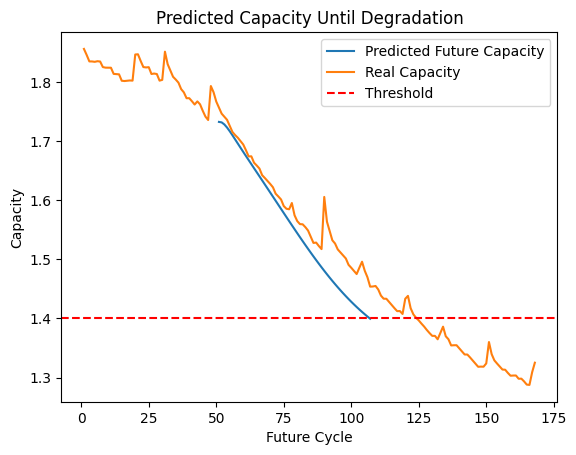

In [30]:
import matplotlib.pyplot as plt

cycles = list(range(SP + 1, SP + len(predicted_capacities) + 1))

plt.plot(cycles, predicted_capacities, label="Predicted Future Capacity")
plt.plot(discharge_data_B0005["cycle_number"], discharge_data_B0005["Capacity"], label="Real Capacity")
plt.axhline(threshold, color='r', linestyle='--', label="Threshold")
plt.xlabel("Future Cycle")
plt.ylabel("Capacity")
plt.legend()
plt.title("Predicted Capacity Until Degradation")
plt.show()

In [31]:
COMPARE_TIMESTEPS = min(TIMESTEPS, predicted_rul)

true_capacities = discharge_data_B0005["Capacity"].values[SP:SP + COMPARE_TIMESTEPS]

predicted_capacities = predicted_capacities[:COMPARE_TIMESTEPS]

len(true_capacities), len(predicted_capacities)

(56, 56)

In [32]:
# Compute RMSE
rmse = np.sqrt(mean_squared_error(true_capacities, predicted_capacities))
# Compute AE
true_rul = 124 - SP
ae = abs(predicted_rul - true_rul)

print(f"rmse: {rmse:.4f}")
print(f"ae: {ae}")

rmse: 0.0433
ae: 18


## Test on other batteries

In [33]:
discharge_data_b0006 = discharge_dataset[discharge_dataset["battery_id"] == "B0006"].copy()

In [34]:
columns = ['Voltage_measured', 'Current_measured', 'Temperature_measured', 'Current_load', 'Voltage_load']
data_path = "../../../dataset/processed/data"

X = prepare_sequences_from_cycles(discharge_data_b0006, data_path, columns)

100%|██████████| 168/168 [00:00<00:00, 223.68it/s]


In [35]:
encoded_features = encoder.predict(X)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


In [36]:
capacity = discharge_data_b0006["Capacity"]

capacity_scaler = MinMaxScaler()

capacity = np.array(capacity)

capacity_scaled = capacity_scaler.fit_transform(capacity.reshape(-1, 1))

capacity_scaled = capacity_scaled.flatten()

combined_features = np.hstack((encoded_features, capacity_scaled.reshape(-1, 1)))

In [37]:
X, y = create_sequences(combined_features, LOOK_BACK)

initial_input = X[SAMPLE_NUM-1:SAMPLE_NUM]
X_input = initial_input.reshape(1, LOOK_BACK, latent_dim + 1)

initial_capacity = X_input[0, 0, -1] # discharge capacity of the first cycle
initial_capacity_real = capacity_scaler.inverse_transform([[initial_capacity]])[0, 0]

threshold = 1.4

print(f"Initial capacity: {initial_capacity_real} Ah")

print (f"Threshold capacity: {threshold} Ah")

Initial capacity: 1.979626548250818 Ah
Threshold capacity: 1.4 Ah


In [38]:
predicted_capacities = []
current_input = X_input.copy()
i = 0

while i < 300:
    y_pred = model.predict(current_input, verbose=0)  # shape: (1, 1, 33)

    capacity_pred = y_pred[0, -1]

    capacity_pred_real = capacity_scaler.inverse_transform([[capacity_pred]])[0, 0]

    predicted_capacities.append(capacity_pred_real)
    print(f"Predicted capacity for cycle {i + SP + 1}: {capacity_pred_real}")

    if capacity_pred_real <= threshold:
        print(f"Predicted capacity for last cycle {i + SP + 1}: {capacity_pred_real}")
        break

    next_step = np.zeros((1, 1, latent_dim + 1))
    next_step[0, 0, :] = y_pred[0, :]

    current_input = np.concatenate([current_input[:, 1:, :], next_step], axis=1)
    i += 1

predicted_rul = i

Predicted capacity for cycle 51: 1.7112430137960102
Predicted capacity for cycle 52: 1.7134052486127531
Predicted capacity for cycle 53: 1.7099262426368347
Predicted capacity for cycle 54: 1.7026298035258167
Predicted capacity for cycle 55: 1.6930392475658333
Predicted capacity for cycle 56: 1.6822149378215396
Predicted capacity for cycle 57: 1.670851015140622
Predicted capacity for cycle 58: 1.6593228967024551
Predicted capacity for cycle 59: 1.647820208903171
Predicted capacity for cycle 60: 1.63642812336597
Predicted capacity for cycle 61: 1.6251725436135158
Predicted capacity for cycle 62: 1.6140449577377525
Predicted capacity for cycle 63: 1.6030145232076385
Predicted capacity for cycle 64: 1.5921097181353108
Predicted capacity for cycle 65: 1.5813163297360224
Predicted capacity for cycle 66: 1.5706255308458632
Predicted capacity for cycle 67: 1.560038240961074
Predicted capacity for cycle 68: 1.5495496524298824
Predicted capacity for cycle 69: 1.5391676729199577
Predicted capacit

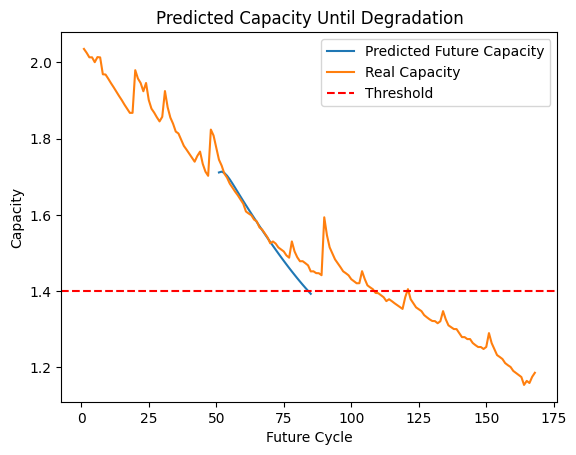

In [39]:
import matplotlib.pyplot as plt

cycles = list(range(SP + 1, SP + len(predicted_capacities) + 1))

plt.plot(cycles, predicted_capacities, label="Predicted Future Capacity")
plt.plot(discharge_data_b0006["cycle_number"], discharge_data_b0006["Capacity"], label="Real Capacity")
plt.axhline(threshold, color='r', linestyle='--', label="Threshold")
plt.xlabel("Future Cycle")
plt.ylabel("Capacity")
plt.legend()
plt.title("Predicted Capacity Until Degradation")
plt.show()

In [40]:
COMPARE_TIMESTEPS = min(TIMESTEPS, predicted_rul)

true_capacities = discharge_data_b0006["Capacity"].values[SP:SP + COMPARE_TIMESTEPS]

predicted_capacities = predicted_capacities[:COMPARE_TIMESTEPS]

len(true_capacities), len(predicted_capacities)

(34, 34)

In [41]:
# Compute RMSE
rmse = np.sqrt(mean_squared_error(true_capacities, predicted_capacities))
# Compute AE
true_rul = 58
ae = abs(predicted_rul - true_rul)

print(f"rmse: {rmse:.4f}")
print(f"ae: {ae}")

rmse: 0.0314
ae: 24


Test on other batteries (B0007)

In [42]:
discharge_data_b0007 = discharge_dataset[discharge_dataset["battery_id"] == "B0007"].copy()

In [43]:
columns = ['Voltage_measured', 'Current_measured', 'Temperature_measured', 'Current_load', 'Voltage_load']
data_path = "../../../dataset/processed/data"

X = prepare_sequences_from_cycles(discharge_data_b0007, data_path, columns)

100%|██████████| 168/168 [00:00<00:00, 185.32it/s]


In [44]:
encoded_features = encoder.predict(X)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


In [45]:
capacity = discharge_data_b0007["Capacity"]

capacity_scaler = MinMaxScaler()

capacity = np.array(capacity)

capacity_scaled = capacity_scaler.fit_transform(capacity.reshape(-1, 1))

capacity_scaled = capacity_scaled.flatten()

combined_features = np.hstack((encoded_features, capacity_scaled.reshape(-1, 1)))

In [46]:
X, y = create_sequences(combined_features, LOOK_BACK)

initial_input = X[SAMPLE_NUM-1:SAMPLE_NUM]
X_input = initial_input.reshape(1, LOOK_BACK, latent_dim + 1)

initial_capacity = X_input[0, 0, -1] # discharge capacity of the first cycle
initial_capacity_real = capacity_scaler.inverse_transform([[initial_capacity]])[0, 0]

threshold = 1.4

print(f"Initial capacity: {initial_capacity_real} Ah")

print (f"Threshold capacity: {threshold} Ah")

Initial capacity: 1.8807805437609768 Ah
Threshold capacity: 1.4 Ah


In [47]:
predicted_capacities = []
current_input = X_input.copy()
i = 0

while i < 300:
    y_pred = model.predict(current_input, verbose=0)  # shape: (1, 1, 33)

    capacity_pred = y_pred[0, -1]

    capacity_pred_real = capacity_scaler.inverse_transform([[capacity_pred]])[0, 0]

    predicted_capacities.append(capacity_pred_real)
    print(f"Predicted capacity for cycle {i + SP + 1}: {capacity_pred_real}")

    if capacity_pred_real <= threshold:
        print(f"Predicted capacity for last cycle {i + SP + 1}: {capacity_pred_real}")
        break

    next_step = np.zeros((1, 1, latent_dim + 1))
    next_step[0, 0, :] = y_pred[0, :]

    current_input = np.concatenate([current_input[:, 1:, :], next_step], axis=1)
    i += 1

predicted_rul = i

Predicted capacity for cycle 51: 1.7760403921136878
Predicted capacity for cycle 52: 1.7743169644210914
Predicted capacity for cycle 53: 1.7707710668451728
Predicted capacity for cycle 54: 1.7660225391606061
Predicted capacity for cycle 55: 1.7605588724691312
Predicted capacity for cycle 56: 1.7547179857421187
Predicted capacity for cycle 57: 1.74871094674829
Predicted capacity for cycle 58: 1.7426591092200083
Predicted capacity for cycle 59: 1.7366149915436169
Predicted capacity for cycle 60: 1.730599121507096
Predicted capacity for cycle 61: 1.7246162947760135
Predicted capacity for cycle 62: 1.7186558380702943
Predicted capacity for cycle 63: 1.712698013132265
Predicted capacity for cycle 64: 1.706752060390703
Predicted capacity for cycle 65: 1.7008082130632929
Predicted capacity for cycle 66: 1.6948604765680744
Predicted capacity for cycle 67: 1.6889084415189626
Predicted capacity for cycle 68: 1.6829482772318756
Predicted capacity for cycle 69: 1.676982849409409
Predicted capacity

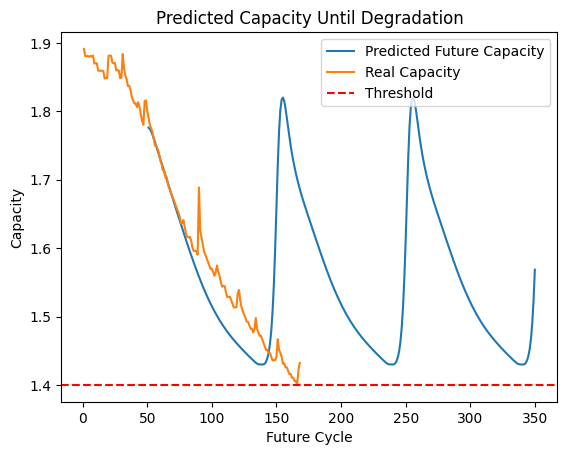

In [48]:
import matplotlib.pyplot as plt

cycles = list(range(SP + 1, SP + len(predicted_capacities) + 1))

plt.plot(cycles, predicted_capacities, label="Predicted Future Capacity")
plt.plot(discharge_data_b0007["cycle_number"], discharge_data_b0007["Capacity"], label="Real Capacity")
plt.axhline(threshold, color='r', linestyle='--', label="Threshold")
plt.xlabel("Future Cycle")
plt.ylabel("Capacity")
plt.legend()
plt.title("Predicted Capacity Until Degradation")
plt.show()

In [49]:
COMPARE_TIMESTEPS = min(TIMESTEPS, predicted_rul)

true_capacities = discharge_data_b0007["Capacity"].values[SP:SP + COMPARE_TIMESTEPS]

predicted_capacities = predicted_capacities[:COMPARE_TIMESTEPS]

len(true_capacities), len(predicted_capacities)

(118, 118)

In [50]:
# Compute RMSE
rmse = np.sqrt(mean_squared_error(true_capacities, predicted_capacities))
# Compute AE
true_rul = 167 - SP
ae = abs(predicted_rul - true_rul)

print(f"rmse: {rmse:.4f}")
print(f"ae: {ae}")

rmse: 0.1383
ae: 183
